### Introduction 

This dataset was retrieved from Kaggle as part of a Data Analysis excersise. 
It contains information regarding the sales of chocolate product by their sales person, country of sales, amount and boxes shipped. 

### This exercise aims to explore the following:

1. Highest vs Lowest Achieving Sales Person
    
    Question: Who has the most and least amount of sales?
    
    Hypotheses: From the overview of the data, the achievement of each Sales Person can be defined in two different ways:
    - By total amount sold, it appears that Juhu Rudeforth will have the highest sale by amount with one sale making $13,685 in sales, while Ches Bonnell will have the lowest with one sale making $574. 
    - By boxes sold, however, if we are judging but the boxes sold per sales person, it appears that Dotty Strutley is the highest, with one sale selling 384 boxes while Gigi Bohling is the least with 91. 

2. Best vs Worst Product
    
    Question: Which product is the most and least popular? 
    
    Hypotheses: Peanut Butter Cubes appears to be the most popular with 3 out of the first 5 purchases have been peanut butter cubes, in reletively high amounts each time, while 85% Dark Bars will be the least popular with only one purchase and the second least boxes shipped.

3. Sale Amount vs Box Sales by Product per Month
    
    Question: 
    - Which product has the highest volume (per box) in sales per month? 
    - Which product has the highest amount($) in sales per month?
    
    Hypotheses: 
    - From the overview Eclairs had the highest volumn of sales in a single month (July 2022)    
    - Peanut Butter Cubes	appears to have the highest overall sale in amount($), totalling $13,685 in the month of Feb-22. 



In [275]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [276]:
df = pd.read_csv('../data/chocolate_sales.csv')

In [277]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [278]:
df.tail()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
1089,Karlen McCaffrey,Australia,Spicy Special Slims,17-May-22,"$4,410",323
1090,Jehu Rudeforth,USA,White Choc,07-Jun-22,"$6,559",119
1091,Ches Bonnell,Canada,Organic Choco Syrup,26-Jul-22,$574,217
1092,Dotty Strutley,India,Eclairs,28-Jul-22,"$2,086",384
1093,Karlen McCaffrey,India,70% Dark Bites,23-May-22,"$5,075",344


In [279]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   1094 non-null   object
 1   Country        1094 non-null   object
 2   Product        1094 non-null   object
 3   Date           1094 non-null   object
 4   Amount         1094 non-null   object
 5   Boxes Shipped  1094 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 51.4+ KB


In [280]:
df['Amount'] = df['Amount'].replace('[$,]', '', regex=True).astype(float)

df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,12726.0,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,13685.0,184


In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales Person   1094 non-null   object 
 1   Country        1094 non-null   object 
 2   Product        1094 non-null   object 
 3   Date           1094 non-null   object 
 4   Amount         1094 non-null   float64
 5   Boxes Shipped  1094 non-null   int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 51.4+ KB


In [282]:
unique_countries_sorted = sorted(df['Country'].unique())
unique_countries_sorted

['Australia', 'Canada', 'India', 'New Zealand', 'UK', 'USA']

In [283]:
countries = {
    'UK': 'United Kingdom',
    'USA': 'United States'
}

df['Country'] = df['Country'].replace(countries)

In [284]:
df['Country'].value_counts()

Country
Australia         205
India             184
United States     179
United Kingdom    178
Canada            175
New Zealand       173
Name: count, dtype: int64

In [285]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,United Kingdom,Mint Chip Choco,04-Jan-22,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,12726.0,342
4,Jehu Rudeforth,United Kingdom,Peanut Butter Cubes,24-Feb-22,13685.0,184


In [286]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')

In [287]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,United Kingdom,Mint Chip Choco,2022-01-04,5320.0,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342
4,Jehu Rudeforth,United Kingdom,Peanut Butter Cubes,2022-02-24,13685.0,184


In [288]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   1094 non-null   object        
 1   Country        1094 non-null   object        
 2   Product        1094 non-null   object        
 3   Date           1094 non-null   datetime64[ns]
 4   Amount         1094 non-null   float64       
 5   Boxes Shipped  1094 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 51.4+ KB


In [289]:
df.to_csv('cleaned_chocolate_sales.csv', index=False)

In [290]:
df = pd.read_csv('../notebooks/cleaned_chocolate_sales.csv')

In [291]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales Person   1094 non-null   object 
 1   Country        1094 non-null   object 
 2   Product        1094 non-null   object 
 3   Date           1094 non-null   object 
 4   Amount         1094 non-null   float64
 5   Boxes Shipped  1094 non-null   int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 51.4+ KB


In [292]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

In [293]:
sales_per_person = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)
box_sales_person = df.groupby('Sales Person')['Boxes Shipped'].sum().sort_values(ascending=False)
products_sold = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
box_product_sold = df.groupby('Product')['Boxes Shipped'].sum().sort_values(ascending=False)
grouped_sales = df.groupby(['Country', 'Product'])['Amount'].sum().reset_index()

In [294]:
print(sales_per_person)

Sales Person
Ches Bonnell           320901.0
Oby Sorrel             316645.0
Madelene Upcott        316099.0
Brien Boise            312816.0
Kelci Walkden          311710.0
Van Tuxwell            303149.0
Dennison Crosswaite    291669.0
Beverie Moffet         278922.0
Kaine Padly            266490.0
Marney O'Breen         259742.0
Barr Faughny           258713.0
Roddy Speechley        251062.0
Gunar Cockshoot        238483.0
Gigi Bohling           232666.0
Karlen McCaffrey       223895.0
Jehu Rudeforth         220976.0
Jan Morforth           219667.0
Curtice Advani         216461.0
Rafaelita Blaksland    210245.0
Husein Augar           205212.0
Andria Kimpton         201747.0
Mallorie Waber         200592.0
Camilla Castle         196616.0
Dotty Strutley         190624.0
Wilone O'Kielt         138523.0
Name: Amount, dtype: float64


In [295]:
print(box_sales_person)

Sales Person
Karlen McCaffrey       9658
Beverie Moffet         9214
Dennison Crosswaite    8767
Kelci Walkden          8702
Oby Sorrel             8608
Brien Boise            8102
Marney O'Breen         8043
Jan Morforth           7661
Ches Bonnell           7522
Madelene Upcott        7279
Kaine Padly            7253
Jehu Rudeforth         7246
Curtice Advani         7074
Roddy Speechley        6899
Dotty Strutley         6853
Van Tuxwell            6799
Gunar Cockshoot        6677
Andria Kimpton         6448
Barr Faughny           6366
Gigi Bohling           6303
Mallorie Waber         5980
Husein Augar           5849
Camilla Castle         5374
Rafaelita Blaksland    4297
Wilone O'Kielt         4033
Name: Boxes Shipped, dtype: int64


In [296]:
print(products_sold)

Product
Smooth Sliky Salty      349692.0
50% Dark Bites          341712.0
White Choc              329147.0
Peanut Butter Cubes     324842.0
Eclairs                 312445.0
99% Dark & Pure         299796.0
85% Dark Bars           299229.0
Organic Choco Syrup     294700.0
Spicy Special Slims     293454.0
Mint Chip Choco         283969.0
Almond Choco            277536.0
Manuka Honey Choco      275541.0
Milk Bars               269248.0
Raspberry Choco         264740.0
After Nines             261331.0
Fruit & Nut Bars        259147.0
Drinking Coco           256655.0
Orange Choco            256144.0
Baker's Choco Chips     249613.0
Choco Coated Almonds    241486.0
Caramel Stuffed Bars    231588.0
70% Dark Bites          211610.0
Name: Amount, dtype: float64


In [297]:
print(box_product_sold)

Product
50% Dark Bites          9792
Smooth Sliky Salty      8810
Eclairs                 8757
Caramel Stuffed Bars    8717
Spicy Special Slims     8685
Drinking Coco           8660
Milk Bars               8330
Peanut Butter Cubes     8304
After Nines             8257
White Choc              8240
Mint Chip Choco         8207
99% Dark & Pure         8127
70% Dark Bites          8015
85% Dark Bars           7793
Manuka Honey Choco      7781
Organic Choco Syrup     7749
Fruit & Nut Bars        7738
Orange Choco            7732
Raspberry Choco         7115
Baker's Choco Chips     6998
Almond Choco            6736
Choco Coated Almonds    6464
Name: Boxes Shipped, dtype: int64


In [298]:
print(grouped_sales)

           Country              Product   Amount
0        Australia       50% Dark Bites  89222.0
1        Australia       70% Dark Bites  39354.0
2        Australia        85% Dark Bars  38479.0
3        Australia      99% Dark & Pure  54908.0
4        Australia          After Nines  27769.0
..             ...                  ...      ...
127  United States  Peanut Butter Cubes  33628.0
128  United States      Raspberry Choco  83524.0
129  United States   Smooth Sliky Salty  45493.0
130  United States  Spicy Special Slims  25214.0
131  United States           White Choc  67221.0

[132 rows x 3 columns]


In [299]:
df['YearMonth'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth')['Boxes Shipped'].sum().reset_index()
print(monthly_sales)

  YearMonth  Boxes Shipped
0   2022-01          27535
1   2022-02          18015
2   2022-03          19561
3   2022-04          21003
4   2022-05          21856
5   2022-06          26260
6   2022-07          22876
7   2022-08          19901


In [300]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,YearMonth
0,Jehu Rudeforth,United Kingdom,Mint Chip Choco,2022-01-04,5320.0,180,2022-01
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94,2022-08
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91,2022-07
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342,2022-04
4,Jehu Rudeforth,United Kingdom,Peanut Butter Cubes,2022-02-24,13685.0,184,2022-02


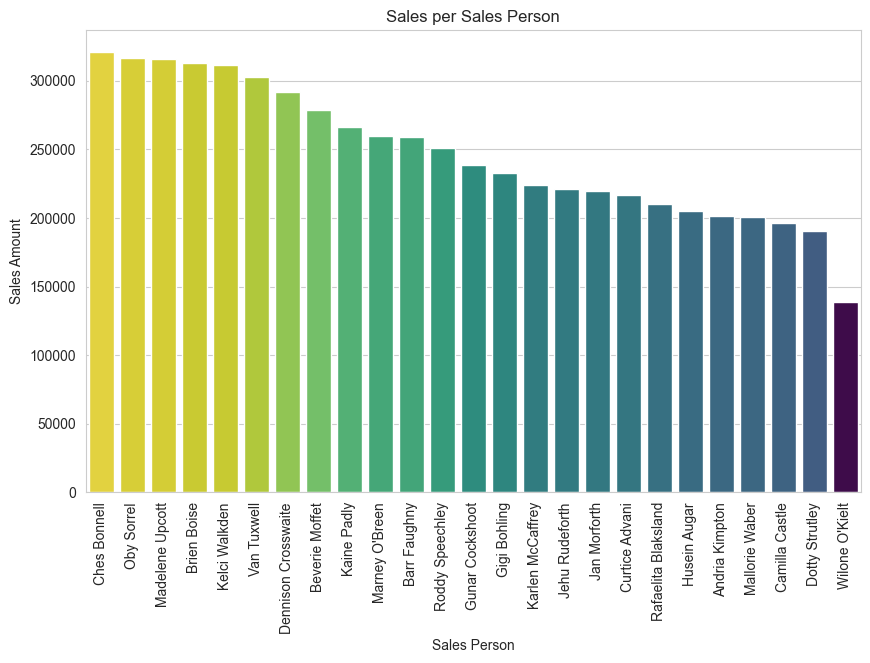

In [301]:
plt.figure(figsize=(10, 6))
sns.barplot(x=sales_per_person.index, y=sales_per_person.values, palette='viridis', hue=sales_per_person.head(25), legend=False)
plt.xticks(rotation=90)
plt.title('Sales per Sales Person')
plt.xlabel('Sales Person')
plt.ylabel('Sales Amount')
plt.show()

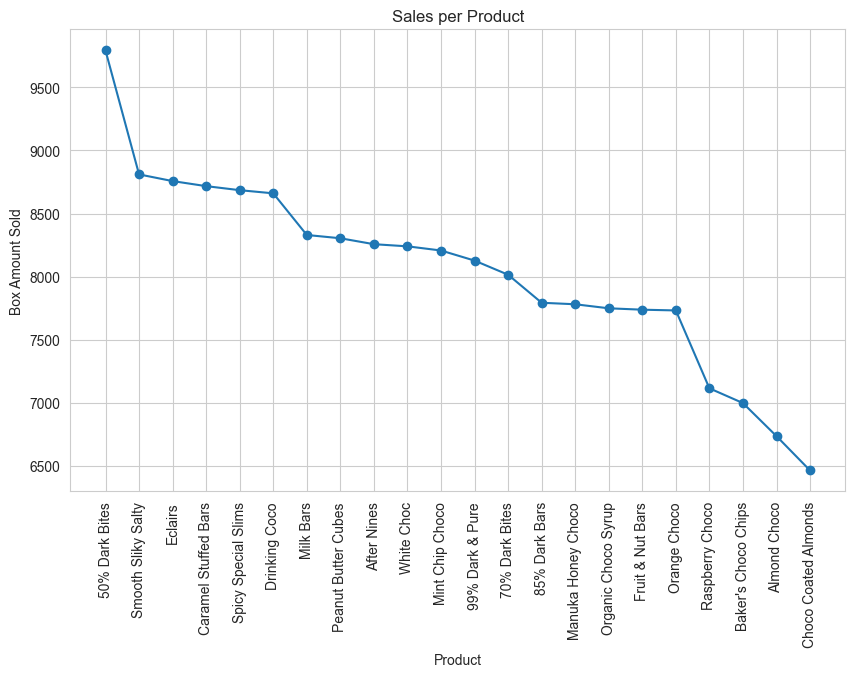

In [325]:
plt.figure(figsize=(10, 6))
plt.plot(box_product_sold.index, box_product_sold.values, marker='o')
plt.title('Sales per Product')
plt.xlabel('Product')
plt.ylabel('Box Amount Sold')
plt.xticks(rotation=90)
plt.show()

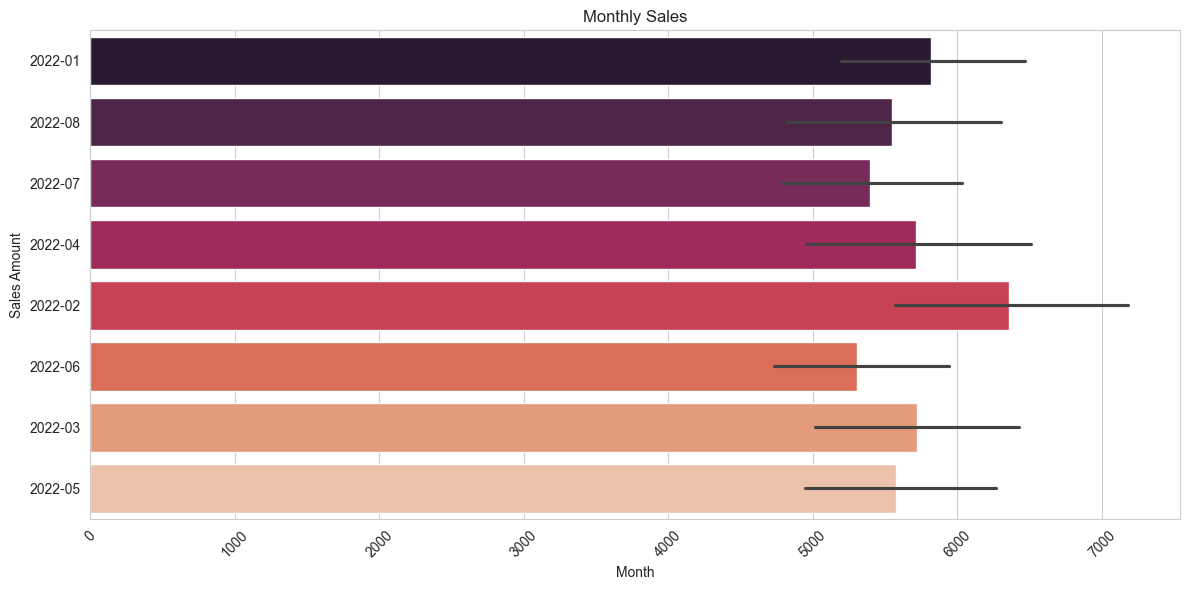

In [311]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Amount', y='YearMonth', data=df, palette='rocket', hue='YearMonth', legend=False)
plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

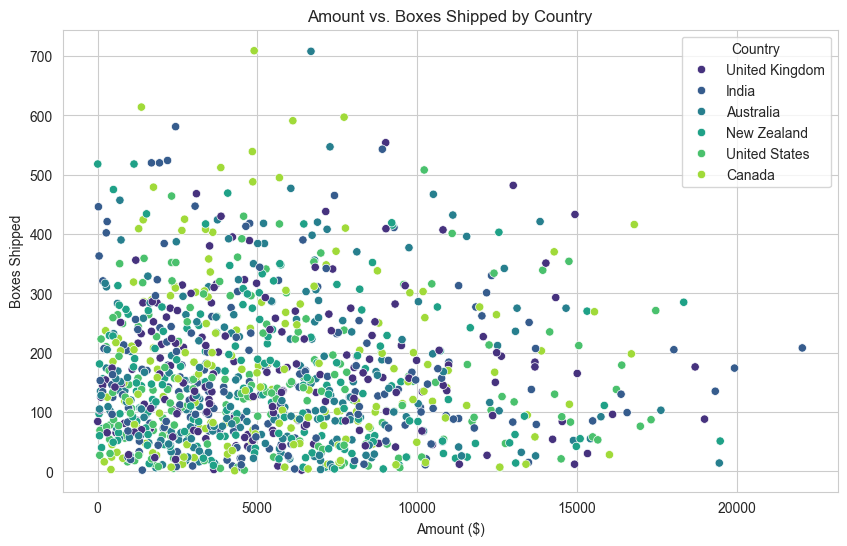

In [350]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Amount', y='Boxes Shipped', hue='Country', palette='viridis')

plt.title('Amount vs. Boxes Shipped by Country')
plt.xlabel('Amount ($)')
plt.ylabel('Boxes Shipped')
plt.show()

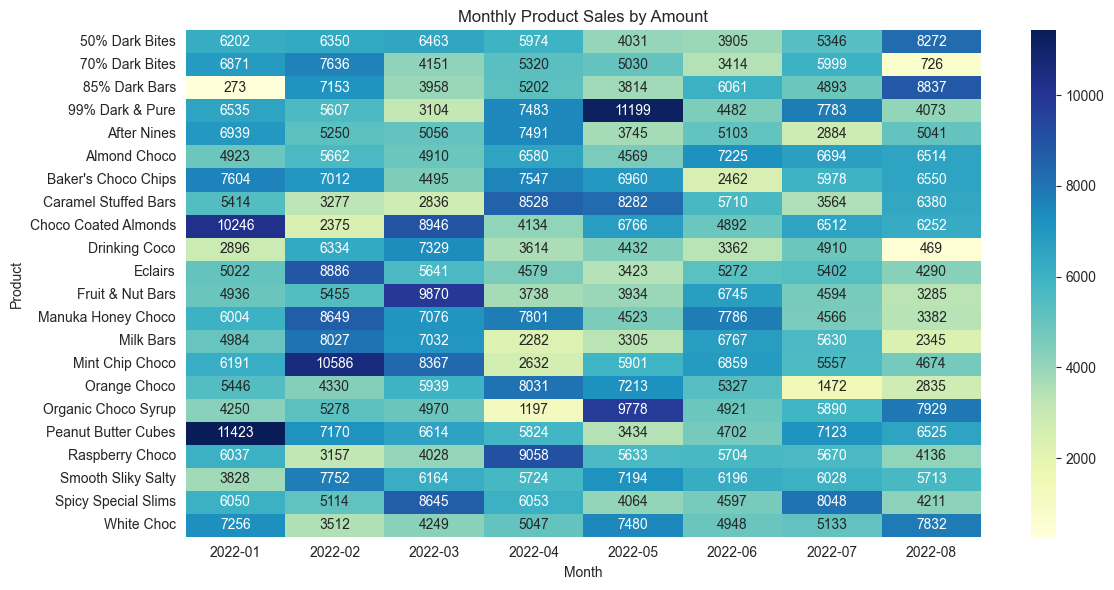

In [352]:
pivot_table = df.pivot_table(index='Product', columns='YearMonth', values='Amount')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Monthly Product Sales by Amount')
plt.xlabel('Month')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


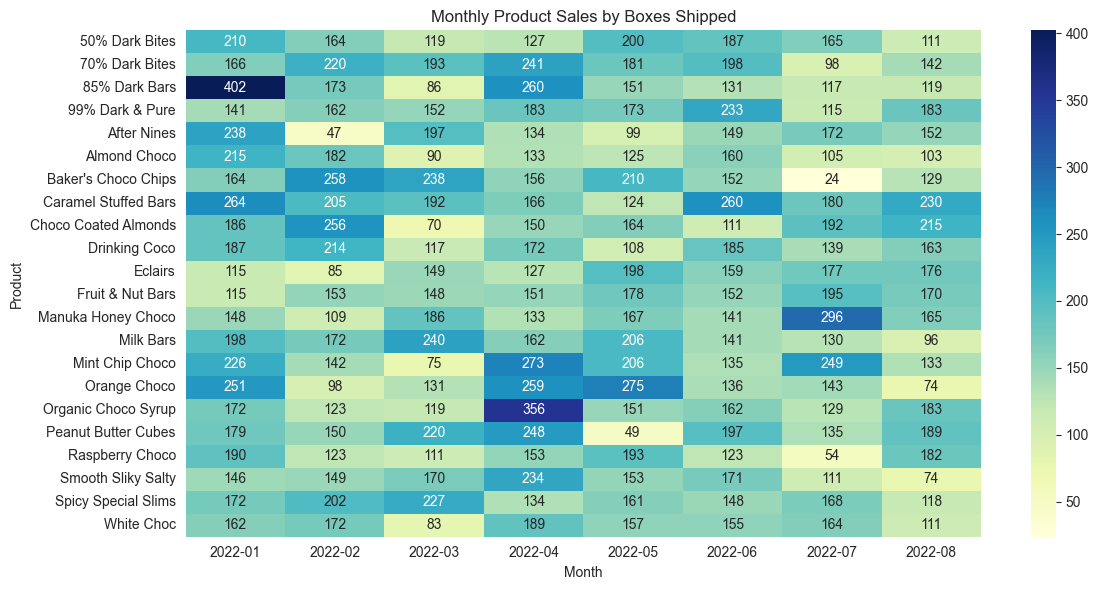

In [351]:
pivot_table = df.pivot_table(index='Product', columns='YearMonth', values='Boxes Shipped')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Monthly Product Sales by Boxes Shipped')
plt.xlabel('Month')
plt.ylabel('Product')
plt.tight_layout()
plt.show()